# Clip v2 (maybe I'll be less confused)

In [8]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [9]:
import os
from dataset import VOC_CLASSES, WSSSDataset, wsss_collate_fn, make_transform, make_voc_datasets


batch_size = 16
num_workers = min(4, os.cpu_count() or 1)

voc_segmentation, voc_val = make_voc_datasets()

# We define TWO dataloaders. One sequential (for caching), one shuffled (for training).
seq_dataloader = DataLoader(voc_segmentation, batch_size=batch_size, collate_fn=wsss_collate_fn, shuffle=False, num_workers=num_workers, pin_memory=True)
dataloader = DataLoader(voc_segmentation, batch_size=batch_size, collate_fn=wsss_collate_fn, shuffle=True, num_workers=num_workers, pin_memory=True)

print(f"Dataset contains {len(voc_segmentation)} images configued across {num_workers} parallel workers.")

Dataset contains 1464 images configued across 4 parallel workers.


## Step 1: CLIP-ES — text-driven CAMs

The first stage of our pipeline is [CLIP-ES (CVPR 2023)](https://github.com/linyq2117/CLIP-ES).
It uses a frozen CLIP ViT-B/16 plus Grad-CAM on the last attention block to
turn image-level labels into class-specific localization maps. The CAMs are
then refined by class-aware attention affinity (CAA) using the model's own
self-attention.

The repo's `clip` module is a *modified* version of OpenAI's CLIP (it returns
per-layer attention weights and accepts `H, W` so positional embeddings are
upsampled for arbitrary input resolutions). It also ships a customized
`pytorch_grad_cam`. We vendor the upstream repo at `./clip_es/` and put it on
`sys.path` so its `clip` shadows the pip-installed `openai-clip`.

In [10]:
import sys
import os

CLIP_ES_DIR = os.path.abspath("clip_es")

# CLIP-ES ships a modified `clip` package, a vendored `pytorch_grad_cam`, and
# helper scripts (`clip_text`, `utils`, `generate_cams_voc12`, `eval_cam`).
# These are NOT packaged under a single `clip_es` namespace — each expects to
# be a top-level module (e.g. `pytorch_grad_cam/base_cam.py` does
# `from pytorch_grad_cam.base_cam import ...`, `generate_cams_voc12.py` does
# `import clip` / `from clip_text import ...`). So we add clip_es/ to sys.path
# and import its children directly. We intentionally do NOT install pip's
# `openai-clip` (see pyproject.toml) so `import clip` has nothing to shadow.
if CLIP_ES_DIR not in sys.path:
    sys.path.insert(0, CLIP_ES_DIR)

import clip
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import scale_cam_image
from clip_text import (
    BACKGROUND_CATEGORY,
    class_names,       # raw VOC names — used to index XML labels
    new_class_names,   # augmented prompts — used for the CLIP text encoder
)
from utils import parse_xml_to_dict, scoremap2bbox

# Reuse the CLIP-ES helpers verbatim instead of re-implementing them.
# `generate_cams_voc12` is a script, but its top-level defs are perfectly
# importable — only the `if __name__ == "__main__":` block is gated.
import generate_cams_voc12 as ces
from generate_cams_voc12 import (
    zeroshot_classifier,   # builds per-class text features by template averaging
    reshape_transform,     # ViT (L,N,C) -> (N,C,H,W) for Grad-CAM
    ClipOutputTarget,      # Grad-CAM target = scalar logit for chosen class
    _transform_resize,     # CLIP preprocessing at arbitrary (h, w)
)

assert clip.__file__.startswith(CLIP_ES_DIR), (
    f"`clip` resolved to {clip.__file__}, expected the CLIP-ES vendored copy"
)
print("CLIP-ES `clip` module:", clip.__file__)
print("Foreground classes :", new_class_names)
print("Background classes :", BACKGROUND_CATEGORY)

CLIP-ES `clip` module: /Users/anthony/Code/cs484-wsss/clip_es/clip/__init__.py
Foreground classes : ['aeroplane', 'bicycle', 'bird avian', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair seat', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person with clothes,people,human', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor screen']
Background classes : ['ground', 'land', 'grass', 'tree', 'building', 'wall', 'sky', 'lake', 'water', 'river', 'sea', 'railway', 'railroad', 'keyboard', 'helmet', 'cloud', 'house', 'mountain', 'ocean', 'road', 'rock', 'street', 'valley', 'bridge', 'sign']


In [11]:
import torch

# CLIP-ES's `clip.load` calls `model.float()` automatically when device == "cpu",
# so the fp16 issues in `multi_head_attention_forward` don't bite us there.
# MPS would keep fp16 weights and currently breaks parts of the attention path.
if torch.cuda.is_available():
    clip_device = "cuda"
elif torch.backends.mps.is_available():
    clip_device = "cpu"
else:
    clip_device = "cpu"

CLIP_MODEL_NAME = "ViT-B/16"
print(f"Loading CLIP-ES backbone {CLIP_MODEL_NAME!r} on {clip_device} (this downloads ~340MB on first run)")
clip_model, _ = clip.load(CLIP_MODEL_NAME, device=clip_device)
clip_model.eval()
print("CLIP loaded")

# `zeroshot_classifier` reads a module-level `device` variable in the original
# script (it's only defined inside its `if __name__ == "__main__":` block),
# so we inject it before calling.
ces.device = clip_device

# Single-template "a clean origami {}." is what CLIP-ES uses by default; it
# acts as a mild domain prompt that empirically gives sharper CAMs on VOC.
PROMPT_TEMPLATES = ["a clean origami {}."]
fg_text_features = zeroshot_classifier(new_class_names,    PROMPT_TEMPLATES, clip_model)
bg_text_features = zeroshot_classifier(BACKGROUND_CATEGORY, PROMPT_TEMPLATES, clip_model)
print(f"FG text features: {fg_text_features.shape}  BG text features: {bg_text_features.shape}")

Loading CLIP-ES backbone 'ViT-B/16' on cpu (this downloads ~340MB on first run)
CLIP loaded
FG text features: torch.Size([20, 512])  BG text features: torch.Size([25, 512])


In [12]:
import numpy as np
import cv2
from PIL import Image

# Hook the LayerNorm before the last attention block (CLIP-ES choice). Grad-CAM
# uses *its* activations + gradients to compute the saliency map.
target_layers = [clip_model.visual.transformer.resblocks[-1].ln_1]
cam = GradCAM(
    model=clip_model,
    target_layers=target_layers,
    reshape_transform=reshape_transform,
)
print("GradCAM ready, hooked into:", target_layers[0])

GradCAM ready, hooked into: LayerNorm((768,), eps=1e-05, elementwise_affine=True)


Running CLIP-ES on 2007_000032...
Predicted classes (label ids): [0, 14]


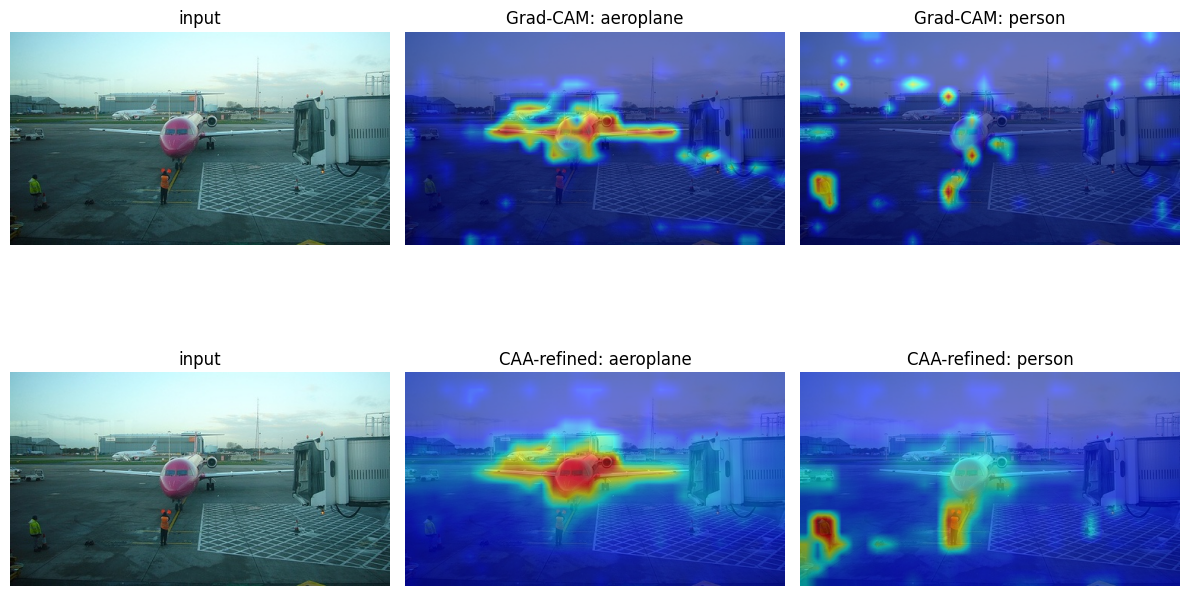

In [13]:
import matplotlib.pyplot as plt
from lxml import etree

VOC_ROOT = "data/VOCdevkit/VOC2012"
PATCH = 16


def run_clip_es_on_image(image_id):
    """Run CLIP-ES end-to-end on one VOC image and return the refined CAMs.

    Pipeline (one image):
      1. Resize to a patch-aligned (H, W) and CLIP-normalize.
      2. Run the ViT once to get image_features + per-layer attention weights.
      3. For each present class, Grad-CAM the last block w.r.t. that class
         logit -> coarse CAM at the patch grid.
      4. Box the high-CAM region, build a class-aware affinity matrix from the
         averaged attention of the last 8 blocks, and propagate the CAM
         through it (this is the CAA refinement step from the paper).
    Returns a dict with per-class refined CAMs at the original image size.

    This is a re-implementation of the original code. Much is copied.
    """
    img_path = os.path.join(VOC_ROOT, "JPEGImages", f"{image_id}.jpg")
    xml_path = os.path.join(VOC_ROOT, "Annotations", f"{image_id}.xml")

    # Same XML loading dance as CLIP-ES's own perform() loop, just spelled out:
    # parse_xml_to_dict gives us a nested dict; we pull out (W, H, present
    # class names) and dedupe the names in source order.
    with open(xml_path) as f:
        data = parse_xml_to_dict(etree.fromstring(f.read()))["annotation"]
    ori_W, ori_H = int(data["size"]["width"]), int(data["size"]["height"])
    present_names = []
    for obj in data["object"]:
        if obj["name"] not in present_names:
            present_names.append(obj["name"])

    # XML stores raw VOC names ("person"); we index into class_names to find
    # the matching augmented prompt ("person with clothes,people,human").
    label_id_list = [class_names.index(n) for n in present_names]
    if not label_id_list:
        raise RuntimeError(f"{image_id} has no labeled objects")

    h = int(np.ceil(ori_H / PATCH) * PATCH)
    w = int(np.ceil(ori_W / PATCH) * PATCH)
    image = _transform_resize(h, w)(Image.open(img_path)).unsqueeze(0).to(clip_device)

    # One forward pass: image_features (L,1,C) + per-layer attn (1, L, L)
    image_features, attn_weight_list = clip_model.encode_image(image, h, w)

    fg_temp = fg_text_features[label_id_list]
    text_temp = torch.cat([fg_temp, bg_text_features], dim=0).to(clip_device)
    cam_input = [image_features, text_temp, h, w]

    coarse_cams = {}
    refined_cams = {}
    for col_idx, class_idx in enumerate(label_id_list):
        targets = [ClipOutputTarget(col_idx)]
        grayscale_cam, _logits, attn_weight_last = cam(
            input_tensor=cam_input, targets=targets, target_size=None
        )
        grayscale_cam = grayscale_cam[0]
        coarse_cams[class_idx] = cv2.resize(grayscale_cam, (ori_W, ori_H))

        # CAA: average self-attn from the last 8 blocks (incl. the freshly
        # captured `attn_weight_last`), restrict propagation to the box around
        # the high-CAM region, then use it as an affinity matrix.
        all_attn = attn_weight_list + [attn_weight_last]
        attn = torch.stack([a[:, 1:, 1:] for a in all_attn], dim=0)[-8:]
        attn = attn.mean(dim=0)[0].detach().float().cpu()

        boxes, n_box = scoremap2bbox(grayscale_cam, threshold=0.4, multi_contour_eval=True)
        aff_mask = torch.zeros(grayscale_cam.shape)
        for i in range(n_box):
            x0, y0, x1, y1 = boxes[i]
            aff_mask[y0:y1, x0:x1] = 1
        aff_mask = aff_mask.view(1, -1)

        trans = attn / attn.sum(dim=0, keepdim=True)
        trans = trans / trans.sum(dim=1, keepdim=True)
        for _ in range(2):
            trans = trans / trans.sum(dim=0, keepdim=True)
            trans = trans / trans.sum(dim=1, keepdim=True)
        trans = (trans + trans.T) / 2
        trans = trans @ trans
        trans = trans * aff_mask

        refined = trans @ torch.tensor(grayscale_cam).view(-1, 1)
        refined = refined.view(h // PATCH, w // PATCH).numpy().astype(np.float32)
        refined_cams[class_idx] = scale_cam_image([refined], (ori_W, ori_H))[0]

    # Background CAMs: same Grad-CAM machinery, but targeting each
    # `BACKGROUND_CATEGORY` text feature ("ground", "sky", "building", ...)
    # which sits at offset `len(fg_temp) + bg_local_idx` in `text_temp`. We
    # don't bother CAA-refining these — coarse is enough for negative SAM
    # prompts. The aggregate is the per-pixel max: "this pixel matches *some*
    # background concept strongly", which is exactly what we want to keep SAM
    # off (apron, sky, jet bridge, etc.).
    n_fg = len(fg_temp)
    bg_cam_per_cat = {}
    for bg_local_idx in range(len(bg_text_features)):
        targets = [ClipOutputTarget(n_fg + bg_local_idx)]
        grayscale_cam, _, _ = cam(
            input_tensor=cam_input, targets=targets, target_size=None
        )
        bg_cam_per_cat[BACKGROUND_CATEGORY[bg_local_idx]] = cv2.resize(
            grayscale_cam[0], (ori_W, ori_H)
        )
    bg_cam = np.maximum.reduce(list(bg_cam_per_cat.values()))
    if bg_cam.max() > 0:
        bg_cam = bg_cam / bg_cam.max()

    return {
        "image_path": img_path,
        "image_size": (ori_W, ori_H),
        "labels": label_id_list,
        "coarse": coarse_cams,
        "refined": refined_cams,
        "bg_cam": bg_cam.astype(np.float32),
        "bg_per_cat": bg_cam_per_cat,
    }


def show_cams(result, alpha=0.55):
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    n = len(result["labels"])
    fig, axes = plt.subplots(2, n + 1, figsize=(4 * (n + 1), 8))
    if n == 1:
        axes = axes.reshape(2, 2)
    axes[0, 0].imshow(img); axes[0, 0].set_title("input"); axes[0, 0].axis("off")
    axes[1, 0].imshow(img); axes[1, 0].set_title("input"); axes[1, 0].axis("off")
    for i, c in enumerate(result["labels"]):
        for row, key, label in [(0, "coarse", "Grad-CAM"), (1, "refined", "CAA-refined")]:
            heat = cv2.applyColorMap((result[key][c] * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
            overlay = (alpha * heat + (1 - alpha) * img).clip(0, 255).astype(np.uint8)
            axes[row, i + 1].imshow(overlay)
            axes[row, i + 1].set_title(f"{label}: {new_class_names[c].split(' ')[0]}")
            axes[row, i + 1].axis("off")
    plt.tight_layout(); plt.show()


sample_id = "2007_000032"
print(f"Running CLIP-ES on {sample_id}...")
result = run_clip_es_on_image(sample_id)
print("Predicted classes (label ids):", result["labels"])
show_cams(result)

DINO Step

In [14]:
# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load DINOv3 (Frozen Foundation Model)
print("Loading DINOv3 (ViT-Small)...")
dino_repo_dir = "./dinov3"
dino_model = torch.hub.load(
    dino_repo_dir,
    "dinov3_vits16",
    source="local",
    weights="weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
).to(device)
dino_model.eval()

Using device: cpu
Loading DINOv3 (ViT-Small)...


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

Refining 2007_000032 with DINO patch-token affinity (anchored, class-masked)...


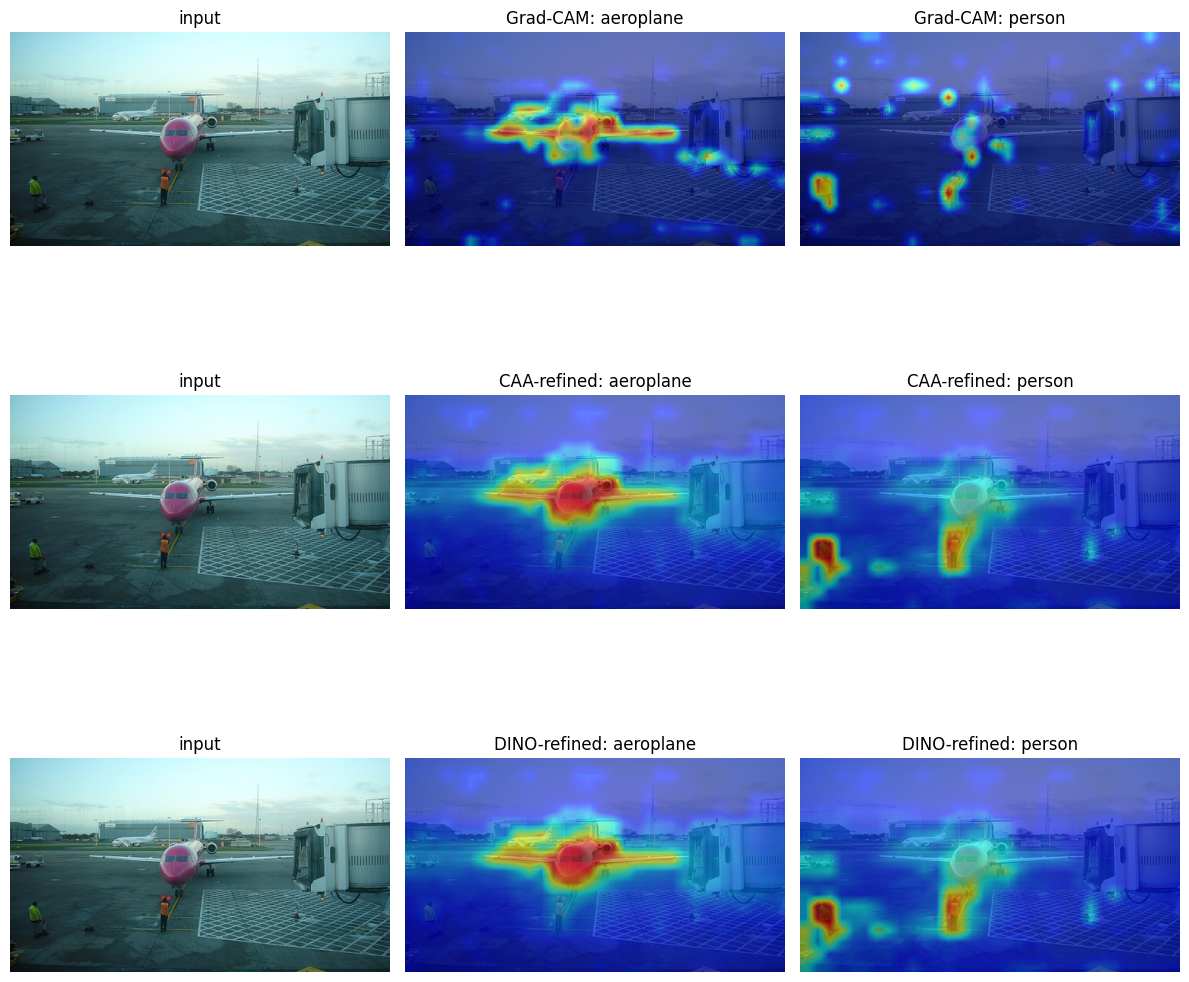

In [15]:
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, InterpolationMode

# DINOv3 was trained with ImageNet stats; CLIP-ES used CLIP's own stats. We
# need a separate preprocess so DINO sees the distribution it expects.
DINO_MEAN = (0.485, 0.456, 0.406)
DINO_STD  = (0.229, 0.224, 0.225)


def _dino_transform(h, w):
    """Resize to (h, w) — same patch-aligned grid as CLIP-ES — then ImageNet norm."""
    return Compose([
        Resize((h, w), interpolation=InterpolationMode.BICUBIC),
        lambda im: im.convert("RGB"),
        ToTensor(),
        Normalize(DINO_MEAN, DINO_STD),
    ])


@torch.no_grad()
def dino_patch_affinity(image_path, h, w, dino_model, device, sim_threshold=0.85):
    """Compute the (N, N) DINO patch-token cosine affinity matrix for an image.

    DINO is class-agnostic: this single matrix is reused to refine every class.
    It encodes "which patches look like they belong to the same physical
    surface/object" according to DINOv3's self-supervised features.

    Steps:
      1. Run DINOv3 once -> patch tokens of shape (N, D), N = (h/16) * (w/16).
      2. L2-normalize so dot product == cosine similarity.
      3. Build A = tokens @ tokens.T (dense affinity).
      4. Sparsify: zero out edges with similarity below `sim_threshold`. DINOv3
         features are generously similar across same-surface patches; without
         a strict threshold the random walk smears every class's activation
         across the whole foreground.
      5. Row-normalize so A is a valid stochastic transition matrix.
    """
    img = Image.open(image_path)
    x = _dino_transform(h, w)(img).unsqueeze(0).to(device)

    out = dino_model.forward_features(x)
    tokens = out["x_norm_patchtokens"][0].float()                # (N, D)
    tokens = F.normalize(tokens, dim=-1)
    A = tokens @ tokens.T                                        # (N, N)
    A = torch.where(A > sim_threshold, A, torch.zeros_like(A))
    A = A / A.sum(dim=-1, keepdim=True).clamp_min(1e-8)
    return A


def _class_aware_mask(cam_patch, mask_threshold=0.4):
    """CLIP-ES style: bounding-box of the high-CAM region, as a flat mask.

    Returns a (N,) torch tensor that is 1 inside any of the (potentially
    multiple) connected components of `cam_patch > mask_threshold * max`,
    expanded to their axis-aligned bboxes, and 0 elsewhere. Used to gate
    the affinity matrix per class so DINO propagation can't leave that
    class's region.
    """
    nh, nw = cam_patch.shape
    boxes, n_box = scoremap2bbox(
        cam_patch, threshold=mask_threshold, multi_contour_eval=True
    )
    mask = np.zeros((nh, nw), dtype=np.float32)
    for i in range(n_box):
        x0, y0, x1, y1 = boxes[i]
        mask[y0:y1, x0:x1] = 1.0
    return torch.tensor(mask.reshape(-1), dtype=torch.float32)


def dino_refine(
    result,
    dino_model,
    device,
    sim_threshold=0.85,        # Fix 1: tighter affinity than the 0.5 default
    hops=1,                    # Fix 1: 1 hop rarely over-smooths; 2+ usually does
    use_class_mask=True,       # Fix 2: gate A by the per-class CAA bbox
    mask_threshold=0.4,        # CAM threshold for the box, matches CLIP-ES CAA
    anchor_restricted=True,    # Fix 3: only confident patches broadcast
    seed_threshold=0.4,        # CAM threshold for "this patch is a positive seed"
    keep_seed=True,            # Fix 3: final = max(seed, propagated)
):
    """Augment a CLIP-ES result dict with a DINO-refined CAM per class.

    Three knobs, layered from cheapest -> most aggressive constraint:

      Fix 1 (sim_threshold, hops): tighter affinity, fewer steps. Just dials.
      Fix 2 (use_class_mask):      multiply A by per-class bbox mask. Same trick
                                   CLIP-ES's CAA uses; makes DINO class-aware
                                   *via the seed* even though A is shared.
      Fix 3 (anchor_restricted):   only patches above `seed_threshold` get to
                                   broadcast. Then we take max(seed, propagated)
                                   so we never erase confident pixels — DINO
                                   can only *fill in* nearby similar patches,
                                   not dim the ones we already trust.

    Set use_class_mask=False, anchor_restricted=False, keep_seed=False, hops=2,
    sim_threshold=0.5 to recover the naive "multiply by DINO affinity" baseline.
    """
    img_path = result["image_path"]
    ori_W, ori_H = result["image_size"]
    h = int(np.ceil(ori_H / PATCH) * PATCH)
    w = int(np.ceil(ori_W / PATCH) * PATCH)
    nh, nw = h // PATCH, w // PATCH

    A_full = dino_patch_affinity(img_path, h, w, dino_model, device, sim_threshold).cpu()

    dino_refined = {}
    for c, ref in result["refined"].items():
        cam_patch = cv2.resize(ref, (nw, nh))                            # (nh, nw)
        seed_vec  = torch.tensor(cam_patch.reshape(-1, 1), dtype=torch.float32)

        # Fix 3: zero out low-confidence patches before they get to broadcast.
        if anchor_restricted:
            broadcast_vec = torch.where(
                seed_vec > seed_threshold, seed_vec, torch.zeros_like(seed_vec)
            )
        else:
            broadcast_vec = seed_vec

        # Fix 2: gate A by the per-class CAA bbox, then re-row-normalize.
        if use_class_mask:
            class_mask = _class_aware_mask(cam_patch, mask_threshold)    # (N,)
            A = A_full * class_mask[None, :]                             # mask cols
            A = A / A.sum(dim=-1, keepdim=True).clamp_min(1e-8)
        else:
            A = A_full

        prop = broadcast_vec
        for _ in range(hops):
            prop = A @ prop

        # Fix 3: keep the strong seed activations even if propagation diluted them.
        final = torch.maximum(seed_vec, prop) if keep_seed else prop

        cam_p = final.view(nh, nw).numpy().astype(np.float32)
        dino_refined[c] = scale_cam_image([cam_p], (ori_W, ori_H))[0]

    return {**result, "dino_refined": dino_refined}


def show_cams_with_dino(result, alpha=0.55):
    """Side-by-side: input | Grad-CAM | CAA-refined | DINO-refined for each class."""
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    rows = [
        ("coarse",       "Grad-CAM"),
        ("refined",      "CAA-refined"),
        ("dino_refined", "DINO-refined"),
    ]
    n = len(result["labels"])
    fig, axes = plt.subplots(len(rows), n + 1, figsize=(4 * (n + 1), 4 * len(rows)))
    for r in range(len(rows)):
        axes[r, 0].imshow(img); axes[r, 0].set_title("input"); axes[r, 0].axis("off")
    for i, c in enumerate(result["labels"]):
        for r, (key, label) in enumerate(rows):
            heat = cv2.applyColorMap((result[key][c] * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
            overlay = (alpha * heat + (1 - alpha) * img).clip(0, 255).astype(np.uint8)
            axes[r, i + 1].imshow(overlay)
            axes[r, i + 1].set_title(f"{label}: {new_class_names[c].split(' ')[0]}")
            axes[r, i + 1].axis("off")
    plt.tight_layout(); plt.show()


print(f"Refining {sample_id} with DINO patch-token affinity (anchored, class-masked)...")
result_with_dino = dino_refine(result, dino_model, device)
show_cams_with_dino(result_with_dino)

## Step 3: SAM2 — turn refined CAMs into pixel-perfect masks

The DINO-refined CAMs are class-discriminative and reasonably tight, but
they're still soft heatmaps at coarse resolution. SAM2 takes them to a
binary, boundary-snapped pseudo-mask.

In [16]:
SAM_CONFIG     = "configs/sam2.1/sam2.1_hiera_t.yaml"
SAM_CHECKPOINT = "weights/sam2.1_hiera_tiny.pt"

print(f"Loading SAM2 ({SAM_CHECKPOINT}) on {device}...")
sam_model     = build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=str(device))
sam_predictor = SAM2ImagePredictor(sam_model)
print("SAM2 ready")


Loading SAM2 (weights/sam2.1_hiera_tiny.pt) on cpu...
SAM2 ready


Running SAM2 on the DINO-refined CAMs of 2007_000032...


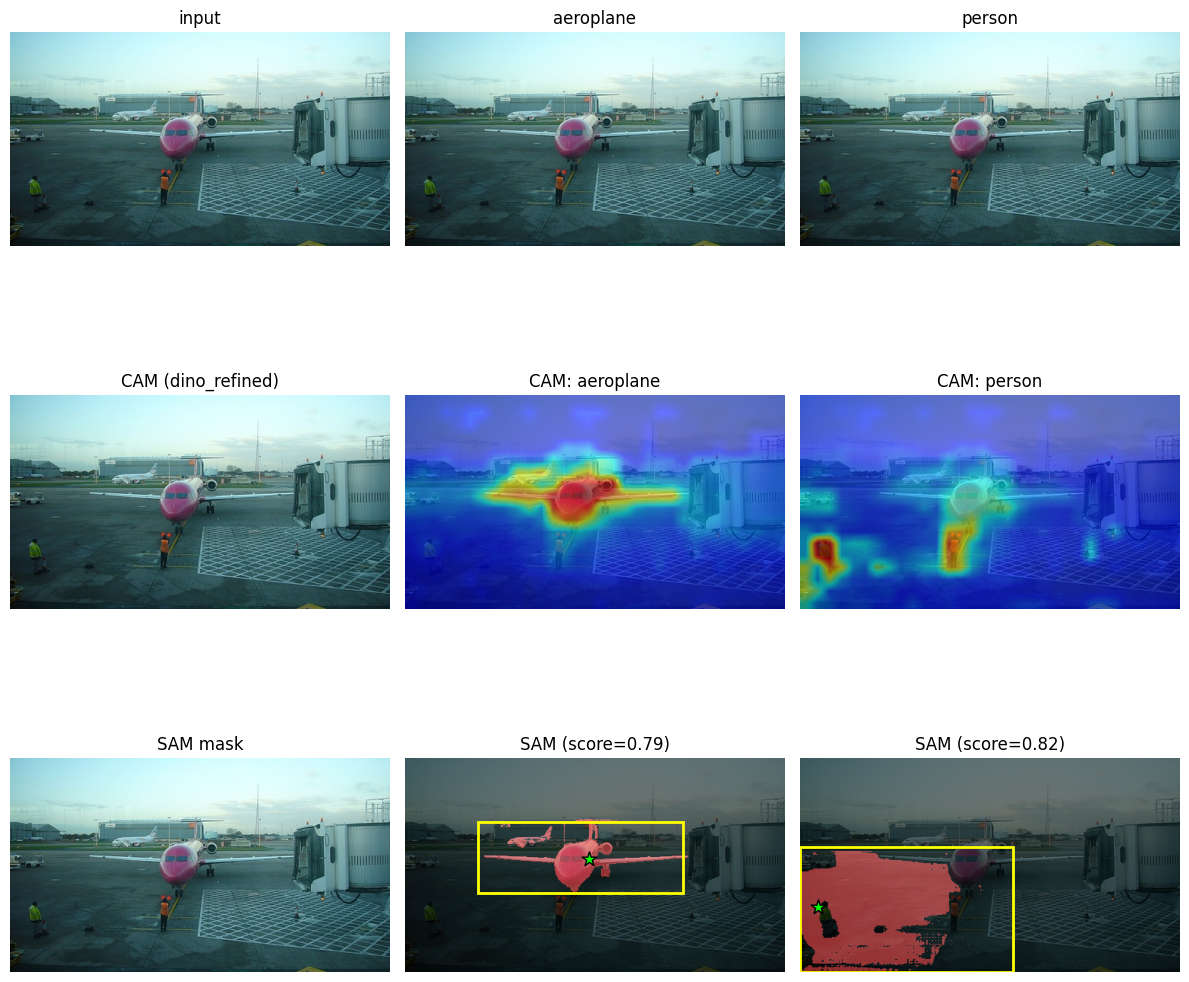

In [17]:
def _cam_to_sam_prompts(cam, cam_threshold=0.4):
    """Mirror `unified.ipynb`'s prompt extraction, but for one CAM at full image res.

    Returns (point_xy, box_xyxy_or_None) in *original image coordinates*.
    SAM2's predict() handles the internal resize to 1024x1024, so unlike the
    unified notebook we don't pre-scale anything.

      point: argmax of the min-max normalized CAM   -> positive click
      box  : axis-aligned bbox of {cam_norm > 0.4}  -> tightens SAM's search
             (None if the threshold yields nothing, just like unified)
    """
    H, W = cam.shape
    cam_min = float(cam.min())
    cam_max = float(cam.max())
    cam_norm = (cam - cam_min) / (cam_max - cam_min + 1e-8)

    flat_idx = int(cam_norm.argmax())
    py, px = divmod(flat_idx, W)
    point_xy = np.array([[px, py]], dtype=np.float32)

    ys, xs = np.where(cam_norm > cam_threshold)
    if ys.size == 0:
        box_xyxy = None
    else:
        box_xyxy = np.array(
            [xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.float32
        )
    return point_xy, box_xyxy


def sam_from_cams(
    result,
    predictor,
    source="dino_refined",
    cam_threshold=0.4,
    use_bg_negative=True,
):
    """Turn the per-class CAMs in `result[source]` into binary SAM2 masks.

    Same prompting recipe as `unified.ipynb`:
      * one positive point at the CAM peak
      * one box from CAM > cam_threshold (skipped if the threshold finds nothing)
      * multimask_output=False -> SAM's single best mask

    Optional `use_bg_negative` adds the bg_cam argmax as a *negative* click —
    the unified notebook doesn't do this (it has no bg signal), but CLIP-ES
    gives us one for free, and it usually helps when the foreground sits on a
    cluttered background.
    """
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    predictor.set_image(img)

    bg_neg = None
    if use_bg_negative and result.get("bg_cam") is not None:
        bg = result["bg_cam"]
        H, W = bg.shape
        flat = int(bg.argmax())
        bg_neg = np.array([[flat % W, flat // W]], dtype=np.float32)

    masks_per_class = {}
    prompts_per_class = {}
    for c, cam in result[source].items():
        point_xy, box_xyxy = _cam_to_sam_prompts(cam, cam_threshold)

        if bg_neg is not None:
            pts = np.concatenate([point_xy, bg_neg], axis=0)
            lbls = np.array([1, 0], dtype=np.int32)
        else:
            pts = point_xy
            lbls = np.array([1], dtype=np.int32)

        masks, scores, _ = predictor.predict(
            point_coords=pts,
            point_labels=lbls,
            box=box_xyxy,
            multimask_output=False,
        )
        masks_per_class[c] = masks[0].astype(bool)  # (H, W)
        prompts_per_class[c] = {
            "point": point_xy,
            "box": box_xyxy,
            "score": float(scores[0]),
        }

    return {
        **result,
        "sam_source": source,
        "sam_masks": masks_per_class,
        "sam_prompts": prompts_per_class,
    }


def show_cams_with_sam(result, alpha=0.55):
    """input | CAM source used | SAM mask + the point/box that produced it."""
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    src = result["sam_source"]
    n = len(result["labels"])
    fig, axes = plt.subplots(3, n + 1, figsize=(4 * (n + 1), 12))

    for r, title in enumerate(["input", f"CAM ({src})", "SAM mask"]):
        axes[r, 0].imshow(img)
        axes[r, 0].set_title(title)
        axes[r, 0].axis("off")

    for i, c in enumerate(result["labels"]):
        cam = result[src][c]
        heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
        cam_overlay = (alpha * heat + (1 - alpha) * img).clip(0, 255).astype(np.uint8)

        mask = result["sam_masks"][c]
        mask_rgb = np.zeros_like(img)
        mask_rgb[mask] = (255, 64, 64)
        mask_overlay = (0.55 * mask_rgb + 0.45 * img).clip(0, 255).astype(np.uint8)

        axes[0, i + 1].imshow(img)
        axes[0, i + 1].set_title(new_class_names[c].split(" ")[0])
        axes[0, i + 1].axis("off")

        axes[1, i + 1].imshow(cam_overlay)
        axes[1, i + 1].set_title(f"CAM: {new_class_names[c].split(' ')[0]}")
        axes[1, i + 1].axis("off")

        axes[2, i + 1].imshow(mask_overlay)
        prompts = result["sam_prompts"][c]
        px, py = prompts["point"][0]
        axes[2, i + 1].scatter([px], [py], s=120, marker="*", c="lime",
                                edgecolors="black", linewidths=1.0)
        if prompts["box"] is not None:
            x0, y0, x1, y1 = prompts["box"]
            axes[2, i + 1].add_patch(plt.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                fill=False, edgecolor="yellow", linewidth=2,
            ))
        axes[2, i + 1].set_title(f"SAM (score={prompts['score']:.2f})")
        axes[2, i + 1].axis("off")

    plt.tight_layout()
    plt.show()


print(f"Running SAM2 on the DINO-refined CAMs of {sample_id}...")
result_with_sam = sam_from_cams(result_with_dino, sam_predictor, source="dino_refined")
show_cams_with_sam(result_with_sam)


## Step 4: mIoU evaluation on VOC 2012 val

We reuse CLIP-ES's `eval_cam.scores` (confusion-matrix mIoU + pixel acc + mean
acc + FW-IoU in one pass) plus their bg-padding / `keys` remap trick. The
heavy per-image pipeline (CLIP-ES → DINO refine → SAM) runs once and feeds
multiple configs (source CAM × SAM gating) in parallel via per-config
histograms — no need to re-run CLIP for an ablation row.


In [18]:
from PIL import Image
from tqdm.auto import tqdm
from eval_cam import _fast_hist  # CLIP-ES vendored

VAL_LIST_PATH = os.path.join(CLIP_ES_DIR, "voc12", "val.txt")
SEG_GT_DIR    = os.path.join(VOC_ROOT, "SegmentationClass")
N_CLASS       = 21  # 20 VOC + bg


def load_val_ids(path=VAL_LIST_PATH, subset=None):
    ids = [ln.strip() for ln in open(path) if ln.strip()]
    return ids[:subset] if subset else ids


def predict_per_image(result, source, use_sam, cam_eval_thres):
    """Per-image (H, W) uint8 prediction in 0..20 (0 = bg).

    Mirrors `clip_es/eval_cam.run_eval_cam`'s inner block:
      - stack per-present-class CAMs into [N_present, H, W]
      - prepend a bg channel (constant `thres` if <1, else (1-max_fg)^thres)
      - argmax + remap local indices through `keys` to global VOC IDs

    `use_sam=True` multiplies each class CAM by its SAM binary mask first, so
    pixels outside SAM agree with no class and fall through to bg.
    """
    keys = np.array(result["labels"], dtype=np.int64)
    cams = np.stack([result[source][c] for c in keys]).astype(np.float32)

    if use_sam:
        masks = np.stack([result["sam_masks"][c] for c in keys]).astype(np.float32)
        cams = cams * masks

    if cam_eval_thres < 1:
        cams = np.pad(cams, ((1, 0), (0, 0), (0, 0)),
                      mode="constant", constant_values=cam_eval_thres)
    else:
        bg = np.power(1.0 - cams.max(axis=0, keepdims=True), cam_eval_thres)
        cams = np.concatenate([bg, cams], axis=0)

    keys_full = np.pad(keys + 1, (1, 0), mode="constant")  # 0 = bg
    return keys_full[cams.argmax(axis=0)].astype(np.uint8)


def metrics_from_hist(hist):
    """Same formulation as `eval_cam.scores`, but takes an accumulated hist.

    Splitting it out lets us stream per image instead of stockpiling preds.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        acc      = np.diag(hist).sum() / hist.sum()
        acc_cls  = np.nanmean(np.diag(hist) / hist.sum(axis=1))
        iu       = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))
        valid    = hist.sum(axis=1) > 0
        mean_iu  = np.nanmean(iu[valid])
        freq     = hist.sum(axis=1) / hist.sum()
        fwavacc  = (freq[freq > 0] * iu[freq > 0]).sum()
    return {
        "Pixel Accuracy":         acc,
        "Mean Accuracy":          acc_cls,
        "Frequency Weighted IoU": fwavacc,
        "Mean IoU":               mean_iu,
        "Class IoU":              dict(zip(range(hist.shape[0]), iu)),
    }


def evaluate(
    val_ids,
    configs=(("dino_refined", False), ("dino_refined", True)),
    cam_eval_thres=2.0,                # CLIP-ES default for "attn"-style refined CAMs
    use_bg_negative=False,
    sam_seed_source="dino_refined",    # which CAM seeds SAM (independent of which CAM scores prediction)
):
    """Run the full pipeline once per image, score every config in `configs`.

    `configs` is a list of (source, use_sam) pairs. SAM is only run if any
    config in the list asks for it.
    """
    need_sam = any(use_sam for _, use_sam in configs)
    hists = {cfg: np.zeros((N_CLASS, N_CLASS), dtype=np.int64) for cfg in configs}
    skipped = []

    for image_id in tqdm(val_ids, desc="Evaluating"):
        try:
            res = run_clip_es_on_image(image_id)
        except Exception as e:
            skipped.append((image_id, repr(e)))
            continue

        res = dino_refine(res, dino_model, device)
        if need_sam:
            res = sam_from_cams(
                res, sam_predictor,
                source=sam_seed_source,
                use_bg_negative=use_bg_negative,
            )

        gt = np.array(Image.open(os.path.join(SEG_GT_DIR, f"{image_id}.png"))).astype(np.uint8)
        gt_flat = gt.flatten()

        for cfg in configs:
            source, use_sam = cfg
            pred = predict_per_image(res, source=source, use_sam=use_sam,
                                     cam_eval_thres=cam_eval_thres)
            hists[cfg] += _fast_hist(gt_flat, pred.flatten(), N_CLASS)

    if skipped:
        print(f"\nSkipped {len(skipped)} image(s); first few: {skipped[:3]}")

    results = {cfg: metrics_from_hist(h) for cfg, h in hists.items()}
    return results, hists


def print_results_table(results, cam_eval_thres):
    """Pretty per-class IoU table, one column per (source, use_sam) config."""
    cfgs = list(results.keys())
    headers = [f"{s}{'+SAM' if sam else ''}" for s, sam in cfgs]
    name_w = max(len(n) for n in (["background"] + VOC_CLASSES))

    print(f"\n=== mIoU report (cam_eval_thres={cam_eval_thres}) ===")
    print("class".ljust(name_w) + " | " + " | ".join(h.center(14) for h in headers))
    print("-" * (name_w + 3 + 17 * len(headers)))
    for c, name in enumerate(["background"] + VOC_CLASSES):
        row = [f"{results[cfg]['Class IoU'][c]:.4f}".center(14) for cfg in cfgs]
        print(name.ljust(name_w) + " | " + " | ".join(row))
    print("-" * (name_w + 3 + 17 * len(headers)))

    for label in ["Mean IoU", "Pixel Accuracy", "Mean Accuracy", "Frequency Weighted IoU"]:
        row = [f"{results[cfg][label]:.4f}".center(14) for cfg in cfgs]
        print(label.ljust(name_w) + " | " + " | ".join(row))


print(f"Found {len(load_val_ids())} val image IDs at {VAL_LIST_PATH}")
print(f"GT segmentation masks at {SEG_GT_DIR}")


Found 1449 val image IDs at /Users/anthony/Code/cs484-wsss/clip_es/voc12/val.txt
GT segmentation masks at data/VOCdevkit/VOC2012/SegmentationClass


In [19]:
# --- Sanity check: 50 images, ~minute or two ---
# When you're happy this works, set SUBSET = None to evaluate the full 1449-image val set.
SUBSET           = 50
CAM_EVAL_THRES   = 2.0          # CLIP-ES paper default for refined CAMs (suppression bg)
USE_BG_NEGATIVE  = True        # try True later to see if bg clicks help SAM

CONFIGS = [
    ("coarse",       False),    # raw CLIP-ES Grad-CAM
    ("refined",      False),    # + CAA refinement
    ("dino_refined", False),    # + DINO affinity refinement (best CAM-only)
    ("dino_refined", True),     # + SAM gating  (best end-to-end)
]

val_ids = load_val_ids(subset=SUBSET)
print(f"Evaluating {len(val_ids)} images across {len(CONFIGS)} configs...")

results, hists = evaluate(
    val_ids,
    configs=CONFIGS,
    cam_eval_thres=CAM_EVAL_THRES,
    use_bg_negative=USE_BG_NEGATIVE,
)
print_results_table(results, CAM_EVAL_THRES)


Evaluating 50 images across 4 configs...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


=== mIoU report (cam_eval_thres=2.0) ===
class       |     coarse     |    refined     |  dino_refined  | dino_refined+SAM
----------------------------------------------------------------------------------
background  |     0.8031     |     0.8446     |     0.8254     |     0.8951    
aeroplane   |     0.4438     |     0.6368     |     0.5628     |     0.7923    
bicycle     |     0.5522     |     0.4661     |     0.4300     |     0.4257    
bird        |     0.3180     |     0.3581     |     0.2738     |     0.8088    
boat        |     0.5605     |     0.3875     |     0.3277     |     0.5376    
bottle      |     0.5503     |     0.6649     |     0.6426     |     0.8262    
bus         |     0.3298     |     0.6970     |     0.7011     |     0.8477    
car         |     0.5094     |     0.6741     |     0.6356     |     0.8482    
cat         |      nan       |      nan       |      nan       |      nan      
chair       |     0.1616     |     0.1003     |     0.0936     |     0.24